# 04 — Model Training & Evaluation

Trains and compares five classifiers on `data_features.csv`, evaluates the best model in detail, and saves all artefacts for notebook 05.

| Step | Output |
|------|--------|
| Load & split | 80 / 20 stratified train/test split |
| Train 5 models | 5-fold CV + held-out test accuracy |
| Comparison chart | `plot_model_comparison.png` |
| Best model report | Per-class precision / recall / F1 |
| Confusion matrix | `plot_confusion_matrix.png` |
| Feature importance | `plot_feature_importance_rf.png` (if RF is best) |
| Baseline check | Single-feature SVM sanity test |
| Save artefacts | `best_model.pkl`, `scaler.pkl`, `label_encoder.pkl`, `feature_cols.pkl` |

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries loaded!')

✅ Libraries loaded!


## Load & Prepare Data

In [2]:
df = pd.read_csv('data_features.csv')

# Normalise label format: ensure labels are '+4', '+10', '+12', '+18'
df['age_group'] = df['age_group'].astype(str).str.strip()
df['age_group'] = df['age_group'].apply(lambda x: '+' + x if not x.startswith('+') else x)
assert set(df['age_group'].unique()) == {'+4', '+10', '+12', '+18'}, 'Unexpected labels!'

feature_cols = [c for c in df.columns if c != 'age_group']
age_order    = ['+4', '+10', '+12', '+18']

X = df[feature_cols].values
y = df['age_group'].values

# Encode labels in age order
le = LabelEncoder()
le.fit(age_order)
y_encoded = le.transform(y)

# Scale features
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f'Age group labels: {sorted(df["age_group"].unique())}')
print(f'✅ Training samples: {len(X_train):,}')
print(f'✅ Test samples:     {len(X_test):,}')
print(f'✅ Features:         {X_train.shape[1]}')
print(f'✅ Classes:          {list(le.classes_)}')

Age group labels: ['+10', '+12', '+18', '+4']
✅ Training samples: 6,400
✅ Test samples:     1,600
✅ Features:         23
✅ Classes:          ['+10', '+12', '+18', '+4']


## Train & Compare Five Models

Each model is evaluated with **5-fold cross-validation on the training set** and then scored on the **held-out test set**. The 80% target line marks the project's minimum accuracy goal.

In [3]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'Naive Bayes':         GaussianNB(),
}

results = {}
print('Training models...\n')

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    model.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, model.predict(X_test))
    results[name] = {
        'cv_mean':       cv_scores.mean(),
        'cv_std':        cv_scores.std(),
        'test_accuracy': test_acc,
    }
    hit = '✅' if test_acc >= 0.80 else '  '
    print(f'{hit} {name:<25}  CV: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}  |  Test: {test_acc:.3f}')

print('\n✅ All models trained!')

Training models...

   Logistic Regression        CV: 0.744 ± 0.006  |  Test: 0.728
   Random Forest              CV: 0.739 ± 0.011  |  Test: 0.749
   Gradient Boosting          CV: 0.748 ± 0.012  |  Test: 0.742
   SVM                        CV: 0.754 ± 0.009  |  Test: 0.751
   Naive Bayes                CV: 0.642 ± 0.032  |  Test: 0.641

✅ All models trained!


## Model Comparison Chart

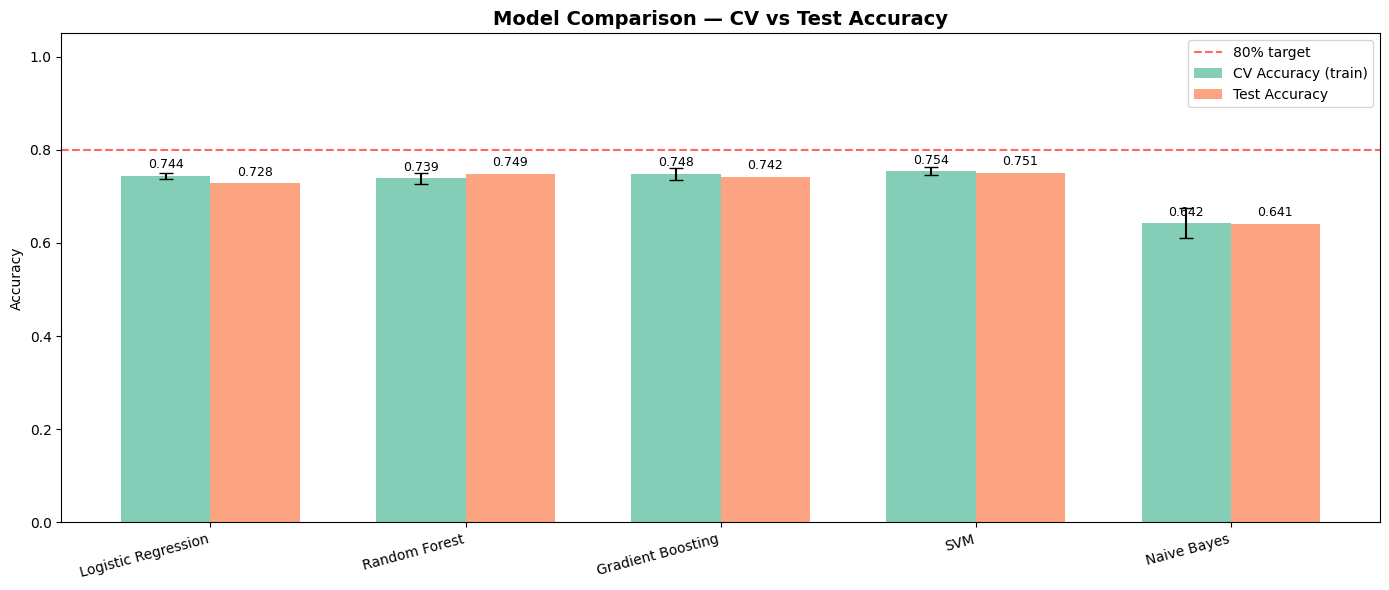

✅ Saved plot_model_comparison.png


In [4]:
names     = list(results.keys())
cv_means  = [results[n]['cv_mean']       for n in names]
cv_stds   = [results[n]['cv_std']        for n in names]
test_accs = [results[n]['test_accuracy'] for n in names]

x     = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, cv_means,  width, yerr=cv_stds,
               label='CV Accuracy (train)', color='#66c2a5', alpha=0.8, capsize=5)
bars2 = ax.bar(x + width/2, test_accs, width,
               label='Test Accuracy',       color='#fc8d62', alpha=0.8)

ax.axhline(0.80, color='red', linestyle='--', alpha=0.6, label='80% target')
ax.set_ylabel('Accuracy')
ax.set_title('Model Comparison — CV vs Test Accuracy', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylim(0, 1.05)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('plot_model_comparison.png', bbox_inches='tight')
plt.show()
print('✅ Saved plot_model_comparison.png')

## Best Model — Detailed Evaluation

In [5]:
best_name  = max(results, key=lambda n: results[n]['test_accuracy'])
best_model = models[best_name]
y_pred     = best_model.predict(X_test)

print(f'🏆 Best model: {best_name}')
print(f'   CV accuracy:   {results[best_name]["cv_mean"]:.3f} ± {results[best_name]["cv_std"]:.3f}')
print(f'   Test accuracy: {results[best_name]["test_accuracy"]:.3f}')
print(f'   Target met:    {"✅ YES" if results[best_name]["test_accuracy"] >= 0.80 else "❌ NO (< 80%)"}')
print()
print(classification_report(y_test, y_pred, target_names=le.classes_))

🏆 Best model: SVM
   CV accuracy:   0.754 ± 0.009
   Test accuracy: 0.751
   Target met:    ❌ NO (< 80%)

              precision    recall  f1-score   support

         +10       0.80      0.69      0.74       400
         +12       0.63      0.64      0.63       400
         +18       0.64      0.75      0.69       400
          +4       0.98      0.92      0.95       400

    accuracy                           0.75      1600
   macro avg       0.76      0.75      0.75      1600
weighted avg       0.76      0.75      0.75      1600



## Confusion Matrix

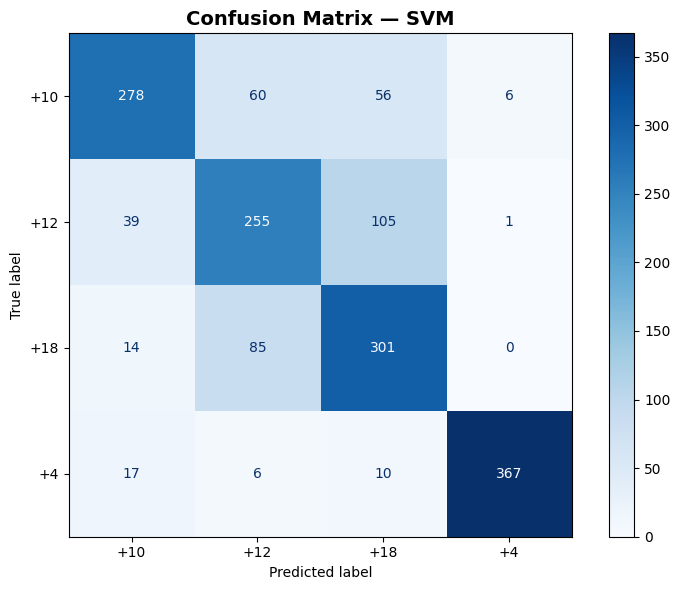

✅ Saved plot_confusion_matrix.png


In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_confusion_matrix.png', bbox_inches='tight')
plt.show()
print('✅ Saved plot_confusion_matrix.png')

## Feature Importance

Shown when the best model is Random Forest or Gradient Boosting (both expose `.feature_importances_`). This identifies which of the 23 features drove classification most strongly.

In [7]:
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=feature_cols)
    importances = importances.sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 8))
    colors = ['#e78ac3' if v >= importances.quantile(0.75) else '#8da0cb' for v in importances]
    importances.plot(kind='barh', ax=ax, color=colors, alpha=0.85)
    ax.set_title(f'Feature Importances — {best_name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.savefig('plot_feature_importance_rf.png', bbox_inches='tight')
    plt.show()
    print('✅ Saved plot_feature_importance_rf.png')
    print('\nTop 5 most important features:')
    print(importances.sort_values(ascending=False).head(5).round(4).to_string())
else:
    print(f'ℹ️  {best_name} does not expose feature importances directly.')
    print('   Run the Logistic Regression coefficients cell below for an alternative.')

# Logistic Regression coefficients (always available as fallback)
lr_model = models['Logistic Regression']
coef_df = pd.DataFrame(
    np.abs(lr_model.coef_),
    index=le.classes_,
    columns=feature_cols
).T
coef_df['mean_abs'] = coef_df.mean(axis=1)
print('\nTop 5 features by mean |coefficient| in Logistic Regression:')
print(coef_df['mean_abs'].sort_values(ascending=False).head(5).round(4).to_string())

ℹ️  SVM does not expose feature importances directly.
   Run the Logistic Regression coefficients cell below for an alternative.

Top 5 features by mean |coefficient| in Logistic Regression:
vocab_richness          1.0636
flesch_reading_ease     1.0497
dale_chall              0.9296
flesch_kincaid_grade    0.8796
num_words               0.8777


## Baseline Sanity Check

Trains an SVM using only `num_words` as a feature. If the full model significantly outperforms this, it confirms the engineered features add real value beyond trivial text-length effects.

In [8]:
X_single        = StandardScaler().fit_transform(df[['num_words']].values)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_single, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

baseline = SVC()
baseline.fit(X_tr, y_tr)
baseline_acc = accuracy_score(y_te, baseline.predict(X_te))
lift = results[best_name]['test_accuracy'] - baseline_acc

print(f'Baseline (num_words only): {baseline_acc:.3f}')
print(f'Best model ({best_name}):  {results[best_name]["test_accuracy"]:.3f}')
print(f'Accuracy lift from features: +{lift:.3f} ({lift*100:.1f} pp)')

Baseline (num_words only): 0.437
Best model (SVM):  0.751
Accuracy lift from features: +0.314 (31.4 pp)


## Save Artefacts

Saves the trained best model, scaler, label encoder, and feature column list for use in notebook 05.

In [9]:
pickle.dump(best_model,   open('best_model.pkl',    'wb'))
pickle.dump(scaler,       open('scaler.pkl',        'wb'))
pickle.dump(le,           open('label_encoder.pkl', 'wb'))
pickle.dump(feature_cols, open('feature_cols.pkl',  'wb'))

print(f'✅ Saved best_model.pkl     ({best_name})')
print(f'✅ Saved scaler.pkl')
print(f'✅ Saved label_encoder.pkl  (classes: {list(le.classes_)})')
print(f'✅ Saved feature_cols.pkl   ({len(feature_cols)} features)')

✅ Saved best_model.pkl     (SVM)
✅ Saved scaler.pkl
✅ Saved label_encoder.pkl  (classes: ['+10', '+12', '+18', '+4'])
✅ Saved feature_cols.pkl   (23 features)
